The first step in the pipeline is to get the xrd data 

In [3]:
from pymatgen.core.structure import Structure
from pymatgen.core.periodic_table import Element
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.diffraction.xrd import XRDCalculator

import pandas as pd

import sys
import os
import numpy as np
#read in the worker number 
try: 
    worker_num = int(sys.argv[1])
except: 
    worker_num = 0

num_splits = 1

print("worker_num", worker_num)
print("num_splits", num_splits)

try: 
    print('using data_dir', str(sys.argv[2]))
    data_dir = str(sys.argv[2])
except:
    data_dir = '/home/gridsan/tmackey/cdvae/data/RRUFF_data_test_only_using_amcsd/'
    print('using the default data_dir', data_dir)

#load in the data. Because this is the RRUFF test data, we only have a test set. 
test_df = pd.read_csv(data_dir + 'test.csv')

# Initialize the XRDCalculator with a wavelength of CuKa (1.54060 Å)
xrd_calculator = XRDCalculator(wavelength='CuKa')
from tqdm.auto import tqdm
tqdm.pandas()

def get_xrd_information(crystal_str):
    try: 
        crystal = Structure.from_str(crystal_str, fmt='cif')
    except:
        crystal = None

    try:  
        xrd = xrd_calculator.get_pattern(crystal)
    except: 
        xrd = None

    try: 
        x = xrd.x.tolist()
        y = xrd.y.tolist()
    except:
        x = None
        y = None

    try: 
        atomic_species = [Element(specie).Z for specie in crystal.species]
    except: 
        atomic_species = None

    return [xrd, x, y, atomic_species]

data_frames = {"test": test_df}

for name, df in data_frames.items():
    
    chunk_size = np.ceil(len(df)/num_splits)
    
    start_index = int(worker_num*chunk_size)
    end_index = int(min(start_index + chunk_size, len(df))) #prevents end index > len(df)
    
    print("start_index", start_index)
    print("end_index", end_index)

    sub_df = df.iloc[start_index:end_index].copy()
    sub_crystals = sub_df['cif'].progress_apply(get_xrd_information)
    sub_df['xrd'] = sub_crystals.progress_apply(lambda x: x[0])
    sub_df['xrd_peak_locations'] = sub_crystals.progress_apply(lambda x: x[1])
    sub_df['xrd_peak_intensities'] = sub_crystals.progress_apply(lambda x: x[2])
    sub_df['atomic_numbers'] = sub_crystals.progress_apply(lambda x: x[3])

    #save the csv
    sub_df.to_csv(data_dir + f'{name}_xrd_{worker_num}.csv', index=False)

worker_num 0
num_splits 1
using the default data_dir /home/gridsan/tmackey/cdvae/data/RRUFF_data_test_only_using_amcsd/
start_index 0
end_index 148


  0%|          | 0/148 [00:00<?, ?it/s]

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))


  0%|          | 0/148 [00:00<?, ?it/s]

  0%|          | 0/148 [00:00<?, ?it/s]

  0%|          | 0/148 [00:00<?, ?it/s]

  0%|          | 0/148 [00:00<?, ?it/s]

next step is merging 

In [4]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import os 

#assuming all of the data was stored as .pt dictionaries of string keys and graph values
num_workers = 1
dataset_names =  ['test']
data_source = "mp_20"
data_dir = f"/home/gridsan/tmackey/cdvae/data/RRUFF_data_test_only_using_amcsd/"

for name in dataset_names:
    total_df = pd.DataFrame()
    for worker_num in tqdm(range(num_workers)):
        df = pd.read_csv(data_dir + f'{name}_xrd_{worker_num}.csv')
        #add df without using append
        total_df = pd.concat([total_df, df])

    output_filepath = os.path.join(data_dir, f'{name}_xrd.csv')
    total_df.to_csv(output_filepath, index=False)
    print(f"Saved {name} dataset")

100%|██████████| 1/1 [00:00<00:00, 40.13it/s]

Saved test dataset


create the disc sim xrd information 

In [6]:
import pandas as pd

import sys
import os
import numpy as np
import ast
from tqdm.auto import tqdm
tqdm.pandas()

#read in the worker number 
try: 
    worker_num = int(sys.argv[1])
except: 
    worker_num = 0

num_splits = 1
data_dir = '/home/gridsan/tmackey/cdvae/data/RRUFF_data_test_only_using_amcsd/'

#load in the data 
test_df = pd.read_csv(data_dir + 'test_xrd.csv')

#let's pull out the diffraction patterns ahead of time 
def simulate_xrd(peak_locations, peak_intensities, lower_bound = 5, upper_bound = 75, dimensions = 200):
    interval =  (upper_bound - lower_bound)/dimensions
    sim_positions = np.arange(lower_bound, upper_bound, interval)
    # Create an empty intensity array for the simulation
    sim_intensities = np.zeros_like(sim_positions)
    
    # Loop over all simulated positions
    for i, pos in enumerate(sim_positions):
        # Find peak locations within 0.25° of the current simulated position
        close_peaks = [(loc, intensity) for loc, intensity in zip(peak_locations, peak_intensities) if abs(loc - pos) <= interval/2]
        
        # If there are close peaks, sum the intensities among those peaks
        if close_peaks:
            intensities = np.array([intensity for loc, intensity in close_peaks])
            sim_intensities[i] = np.sum(intensities)
    
    sim_intensities = 100*sim_intensities / max(sim_intensities)
    
    return sim_intensities

data_frames = {"test": test_df}

for name, df in data_frames.items():
    
    chunk_size = np.ceil(len(df)/num_splits)
    
    start_index = int(worker_num*chunk_size)
    end_index = int(min(start_index + chunk_size, len(df))) #prevents end index > len(df)
    sub_df = df.iloc[start_index:end_index].copy()

    sub_df['xrd_peak_locations'] = sub_df['xrd_peak_locations'].progress_apply(ast.literal_eval)
    sub_df['xrd_peak_intensities'] = sub_df['xrd_peak_intensities'].progress_apply(ast.literal_eval)
    sub_df['disc_sim_xrd'] = sub_df.progress_apply(lambda row: simulate_xrd(row['xrd_peak_locations'], row['xrd_peak_intensities']), axis=1)    

    #save
    sub_df.to_csv(data_dir + f'{name}_xrd_disc_sim_{worker_num}.csv', index=False)

  0%|          | 0/148 [00:00<?, ?it/s]

  0%|          | 0/148 [00:00<?, ?it/s]

  0%|          | 0/148 [00:00<?, ?it/s]

merge

In [7]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import os 
#assuming all of the data was stored as .pt dictionaries of string keys and graph values
num_workers = 1
dataset_names =  ['test']
data_dir = '/home/gridsan/tmackey/cdvae/data/RRUFF_data_test_only_using_amcsd/'

for name in dataset_names:
    total_df = pd.DataFrame()
    for worker_num in tqdm(range(num_workers)):
        df = pd.read_csv(data_dir + f'{name}_xrd_disc_sim_{worker_num}.csv')
        # print(len(df))
        #add df without using append
        total_df = pd.concat([total_df, df])
    output_filepath = os.path.join(data_dir, f'{name}_xrd_disc_sim.csv')
    total_df.to_csv(output_filepath, index=False)
    print(f"Saved {name} dataset")

100%|██████████| 1/1 [00:00<00:00, 29.24it/s]

Saved test dataset


graph data 

In [8]:
import numpy as np
import pandas as pd
import networkx as nx
import torch
import copy
import itertools

from pymatgen.core.structure import Structure
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.graphs import StructureGraph
from pymatgen.analysis import local_env

from networkx.algorithms.components import is_connected

from sklearn.metrics import accuracy_score, recall_score, precision_score

from torch_scatter import scatter

from p_tqdm import p_umap

import ast
#import the random function library
import random

import os 

from tqdm.auto import tqdm
tqdm.pandas()

CrystalNN = local_env.CrystalNN(
    distance_cutoffs=None, x_diff_weight=-1, porous_adjustment=False)

from cdvae.common.data_utils import * 

import sys

#read in the worker number 
try: 
    worker_num = int(sys.argv[1])
except: 
    worker_num = 0

#read in the number of splits
try:
    num_splits = int(sys.argv[2])
except:
    num_splits = 1

data_dir = '/home/gridsan/tmackey/cdvae/data/RRUFF_data_test_only_using_amcsd/'

#load in the data 
test_df = pd.read_csv(data_dir + 'test_xrd.csv')

def build_crystal(crystal_str, niggli=True, primitive=False):
    try: 
        """Build crystal from cif string."""
        crystal = Structure.from_str(crystal_str, fmt='cif')

        if primitive:
            crystal = crystal.get_primitive_structure()

        if niggli:
            crystal = crystal.get_reduced_structure()

        canonical_crystal = Structure(
            lattice=Lattice.from_parameters(*crystal.lattice.parameters),
            species=crystal.species,
            coords=crystal.frac_coords,
            coords_are_cartesian=False,
        )
        # match is gaurantteed because cif only uses lattice params & frac_coords
        # assert canonical_crystal.matches(crystal)
        return canonical_crystal
    except: 
        return None 


def build_crystal_graph(crystal, graph_method='crystalnn'):
    try: 
        """
        """

        if graph_method == 'crystalnn':
            crystal_graph = StructureGraph.with_local_env_strategy(
                crystal, CrystalNN)
        elif graph_method == 'none':
            pass
        else:
            raise NotImplementedError

        frac_coords = crystal.frac_coords
        atom_types = crystal.atomic_numbers
        lattice_parameters = crystal.lattice.parameters
        lengths = lattice_parameters[:3]
        angles = lattice_parameters[3:]

        assert np.allclose(crystal.lattice.matrix,
                        lattice_params_to_matrix(*lengths, *angles))

        edge_indices, to_jimages = [], []
        if graph_method != 'none':
            for i, j, to_jimage in crystal_graph.graph.edges(data='to_jimage'):
                edge_indices.append([j, i])
                to_jimages.append(to_jimage)
                edge_indices.append([i, j])
                to_jimages.append(tuple(-tj for tj in to_jimage))

        atom_types = np.array(atom_types)
        lengths, angles = np.array(lengths), np.array(angles)
        edge_indices = np.array(edge_indices)
        to_jimages = np.array(to_jimages)
        num_atoms = atom_types.shape[0]

        return frac_coords, atom_types, lengths, angles, edge_indices, to_jimages, num_atoms
    except: 
        return None
    
data_frames = {'test': test_df}

for name, df in data_frames.items():
    
    chunk_size = np.ceil(len(df)/num_splits)
    
    start_index = int(worker_num*chunk_size)
    end_index = int(min(start_index + chunk_size, len(df))) #prevents end index > len(df)
    sub_df = df.iloc[start_index:end_index].copy()
    sub_crystals = sub_df['cif'].progress_apply(build_crystal)
    sub_graphs = sub_crystals.progress_apply(build_crystal_graph)

    materials_ids = sub_df['material_id'].values

    #make a dictionary using the materials_ids as keys and the graphs as values
    graph_dict = dict(zip(materials_ids, sub_graphs))

    #save the dictionary to a file
    torch.save(graph_dict, data_dir + '{}_{}.pt'.format(name, worker_num))
    
    print('Saved {}_{}.pt'.format(name, worker_num))

  0%|          | 0/148 [00:00<?, ?it/s]

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))


  0%|          | 0/148 [00:00<?, ?it/s]

Saved test_0.pt


Merging 

In [9]:
import numpy as np
import torch 
from tqdm import tqdm

#assuming all of the data was stored as .pt dictionaries of string keys and graph values
num_workers = 1
dataset_names =  ['test']

data_dir = '/home/gridsan/tmackey/cdvae/data/RRUFF_data_test_only_using_amcsd/'

for name in dataset_names:
    total_dict = {}
    for worker_num in tqdm(range(num_workers)):
        chunk = torch.load(data_dir + '{}_{}.pt'.format(name, worker_num))
        total_dict.update(chunk)
    torch.save(total_dict, data_dir + '{}.pt'.format(name))
    print('Saved {}.pt'.format(name))

100%|██████████| 1/1 [00:00<00:00,  6.43it/s]

Saved test.pt


Because this test data is real xrd data from the RRUFF database, we do not need to generate the pseudo-voights for testing. 

Load in the data to double check 

In [10]:
import pandas as pd
import numpy as np
import torch

In [11]:
train_dict = torch.load('/home/gridsan/tmackey/cdvae/data/RRUFF_data_test_only_using_amcsd/test_pv_xrd.pt')

In [12]:
import matplotlib.pyplot as plt

In [13]:
#get the first key
key = list(train_dict.keys())[1]

In [14]:
key

'Siderite'

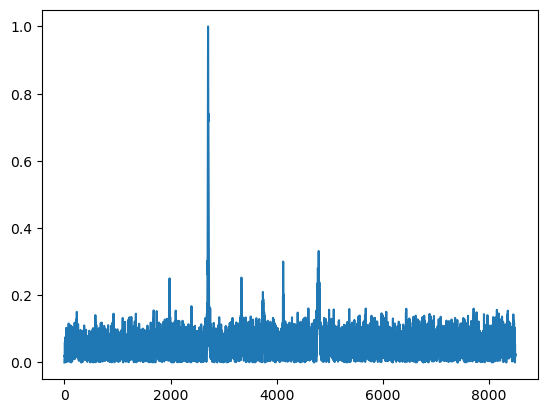

In [15]:
plt.plot(list(train_dict[key].numpy().flatten()))

In [16]:
#finally, move the test_xrd_disc_sim.csv to test.csv 

In [17]:
!mv /home/gridsan/tmackey/cdvae/data/RRUFF_data_test_only_using_amcsd/test_xrd_disc_sim.csv /home/gridsan/tmackey/cdvae/data/RRUFF_data_test_only_using_amcsd/test.csv

In [18]:
#actually, one more step. In order to make the data compatible with the previous models, we need to add a "spacegroup.number" column 
#even though the model doesn't use it anymore, it still expects it.

In [19]:
import pandas as pd

In [20]:
test_df = pd.read_csv('/home/gridsan/tmackey/cdvae/data/RRUFF_data_test_only_using_amcsd/test.csv')

test_df['spacegroup.number'] = 1

test_df.to_csv('/home/gridsan/tmackey/cdvae/data/RRUFF_data_test_only_using_amcsd/test.csv', index=False)